In [1]:
import io
import string
import textwrap

import beaker
import cartopy.crs as ccrs
import faceted
import numpy as np
import pandas as pd
import wandb
import xarray as xr

import plotting

In [2]:
AMIP_CASES = {
    "SHiELD": "01KMGK3MDY5T575NKP62S09YYQ",
    "ACE2-SHiELD": "01KMGKXDBRAKFTDADM4B0A5Z2Q",
    "no-random-co2 energy-conserving rs0": "01KMK72D9T0KTEN48ZYBQ0KH03",
    "full energy-conserving rs0": "01KMJM2H2GY1XSD5H89964S78W",
}
AMIP_PLUS_4K_CASES = {
    "SHiELD": "01KMGRCJ78GJF2029G0KVD7Q7N",
    "ACE2-SHiELD": "01KMJMWQN4AH4CMH6GYYAZPF72",
    "no-random-co2 energy-conserving rs0": "01KMJMX5GX3X8VMFVQ502W40W6",
    "full energy-conserving rs0": "01KMGTF0JG8QV3RK1FE0YNAKFF",
}

In [3]:
FILE_PATH = "test/time_mean_diagnostics.nc"


def open_beaker_dataset(dataset_id: str, path: str) -> xr.Dataset:
    """Given a beaker dataset ID and path within dataset, return an xarray
    dataset.

    Note: dataset must fit in memory. Requires h5netcdf backend.  Adapted from
    ace2-paper repo.
    """
    client = beaker.Beaker.from_env()
    file = client.dataset.get_file(dataset_id, path)
    ds = xr.open_dataset(io.BytesIO(file), engine="h5netcdf").load()
    ds = ds.rename({v: v.replace("gen_map-", "") for v in ds})
    return ds


def open_beaker_datasets(dataset_ids: dict[str, str], path: str) -> xr.Dataset:
    datasets = {}
    for model, dataset_id in dataset_ids.items():
        datasets[model] = open_beaker_dataset(dataset_id, path)
    return xr.concat(datasets.values(), dim="model").assign_coords(model=list(datasets.keys()))

In [4]:
mean_control_ds = open_beaker_datasets(AMIP_CASES, FILE_PATH)
plus_4k_ds = open_beaker_datasets(AMIP_PLUS_4K_CASES, FILE_PATH)
response = plus_4k_ds - mean_control_ds

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Workspace'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Dataset'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(


Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [5]:
aspect_ratio = plotting.get_aspect_ratio(ccrs.Robinson(), (-180, 180, -89.84, 89.84))

In [6]:
MODELS = ["SHiELD", "ACE2-SHiELD", "no-random-co2 energy-conserving rs0", "full energy-conserving rs0"]
LABELS = {
    "SHiELD": "SHiELD",
    "ACE2-SHiELD": "ACE2-SHiELD",
    "no-random-co2 energy-conserving rs0": "ACE2S-SHiELD+$_{\\text{no-RC}}$",
    "full energy-conserving rs0": "ACE2S-SHiELD+",
}

In [7]:
plotting.configure_style()

def plot_response(response, models, variable, long_name, units, filename, scale_factor=1.0, vmin=-15, vmax=15, bottom_pad=0.85):
    fig, axes, (cax1, cax2) = faceted.faceted(
        4, 
        2, 
        aspect=aspect_ratio, 
        width=5.5,
        cbar_pad=0.125,
        internal_pad=0.25,
        cbar_mode="edge", 
        cbar_location="bottom", 
        axes_kwargs={"projection": ccrs.Robinson()},
        left_pad=0.35,
        bottom_pad=bottom_pad,
    )

    cmap = "RdBu_r"
    response = scale_factor * response[variable]
    response_bias = response.drop_sel(model="SHiELD") - response.sel(model="SHiELD")

    weights = np.cos(np.deg2rad(response.lat))
    mean = response.weighted(weights).mean(["lat", "lon"]).compute()
    rmse = np.sqrt((response_bias ** 2).weighted(weights).mean(["lat", "lon"])).compute()

    for ax, model in zip(axes[::2], models):
        p1 = response.sel(model=model).plot(
            ax=ax,
            add_colorbar=False,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
        )
        ax.coastlines()
        ax.set_title(f"Global mean = {mean.sel(model=model).item():0.2f} {units}")

        ax.annotate(
            LABELS[model],
            xy=(0, 0.5),
            xytext=(-17, 0),
            xycoords="axes fraction",
            textcoords="offset points",
            ha="center",
            va="center",
            rotation=90,
        )

    for ax, model in zip(axes[3::2], MODELS[1:]):
        p2 = response_bias.sel(model=model).plot(
            ax=ax,
            add_colorbar=False,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
        )
        ax.coastlines()
        ax.set_title(f"Global RMSE = {rmse.sel(model=model).item():0.2f} {units}")

    for ax, label in zip(axes[::2] + axes[3::2], string.ascii_lowercase):
        ax.annotate(
            f"({label})",
            xy=(0, 1),
            xytext=(2, -2),
            va="top",
            xycoords="axes fraction",
            textcoords="offset points",
        )

    axes[1].set_visible(False)
    label = textwrap.fill(f"2012-2020 mean {long_name} response to a uniform +4 K SST perturbation [{units}]", 40)
    fig.colorbar(p1, cax=cax1, orientation="horizontal", label=label)
    fig.colorbar(p2, cax=cax2, orientation="horizontal", label=f"Bias (ACE minus SHiELD) [{units}]")
    fig.patch.set_alpha(0.0)
    fig.savefig(f"{filename}.png", dpi=300)
    fig.savefig(f"{filename}.pdf")

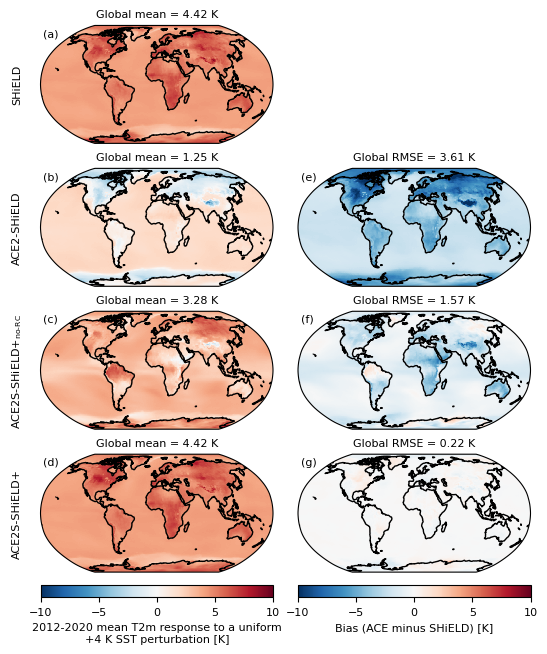

In [8]:
plot_response(response, MODELS, "TMP2m", "T2m", "K", "figure-06", vmin=-10, vmax=10, bottom_pad=0.55)

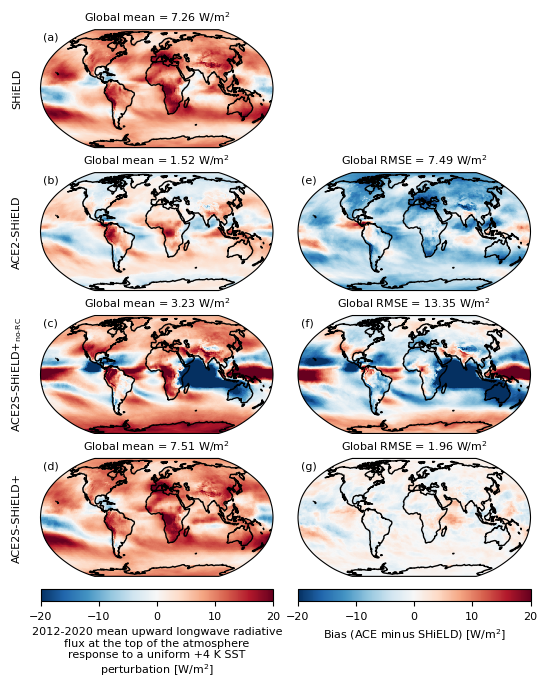

In [9]:
plot_response(response, MODELS, "ULWRFtoa", "upward longwave radiative flux at the top of the atmosphere", "W/m$^2$", "figure-S04", vmin=-20, vmax=20)

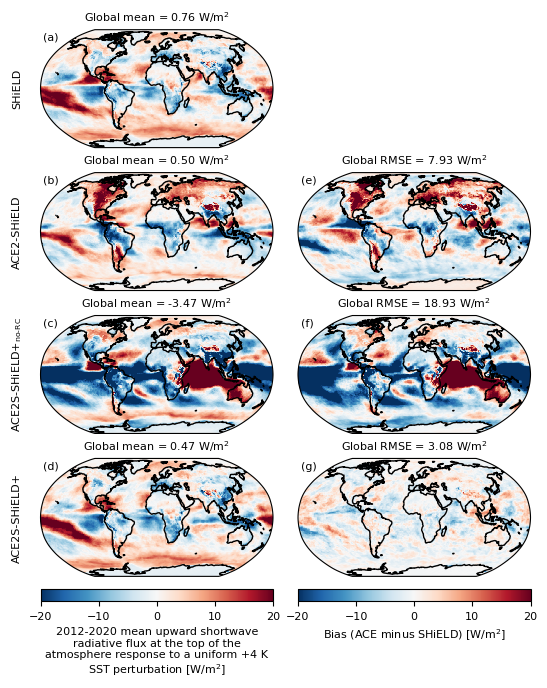

In [10]:
plot_response(response, MODELS, "USWRFtoa", "upward shortwave radiative flux at the top of the atmosphere", "W/m$^2$", "figure-S05", vmin=-20, vmax=20)

In [13]:
import ported_vcm as vcm

VERTICAL_VARIABLES = ["air_temperature", "eastward_wind", "northward_wind"]
REFERNCE_DATASET = "gs://vcm-ml-intermediate/2026-06-08-vertically-resolved-1deg-c96-shield-som-ensemble-fme-dataset/1xCO2-ic_0001.zarr"


def stack_variable(ds, name, levels=8):
    levels = [f"{name}_{n}" for n in range(levels)]
    return ds[levels].to_array(dim="pfull").drop_vars("pfull").rename(name)


def stack_vertically_resolved_fields(ds, variables):
    arrays = []
    for variable in variables:
        da = stack_variable(ds, variable)
        arrays.append(da)
    return xr.merge(arrays)


def pressure_interpolate(ds, variables=VERTICAL_VARIABLES):
    vertical_coordinate = xr.open_zarr(REFERNCE_DATASET)
    ak = stack_variable(vertical_coordinate, "ak", levels=9)
    bk = stack_variable(vertical_coordinate, "bk", levels=9)

    ptop = ak.isel(pfull=0).item()

    delp = (ak + ds["PRESsfc"] * bk).diff("pfull")
    stacked = stack_vertically_resolved_fields(ds, variables)

    standard_delp = (ak + np.float32(100_000) * bk).diff("pfull")
    standard_levels = vcm.pressure_at_midpoint_log(standard_delp, toa_pressure=ak.isel(pfull=0), dim="pfull").rename({"pfull": "pressure"})

    interpolated = vcm.interpolate_to_pressure_levels(
        stacked,
        delp,
        levels=standard_levels,
        dim="pfull",
        ptop=ptop
    )
    weights = standard_delp.rename({"pfull": "pressure"}).where(interpolated.air_temperature.notnull()).sum("lon") * np.cos(np.deg2rad(interpolated.lat))
    return weights, interpolated


In [14]:
_, pressure_interpolated_control = pressure_interpolate(mean_control_ds)
weights, pressure_interpolated_plus_4k = pressure_interpolate(plus_4k_ds)
pressure_interpolated_response = pressure_interpolated_plus_4k - pressure_interpolated_control
pressure_interpolated_response_bias = pressure_interpolated_response.drop_sel(model="SHiELD") - pressure_interpolated_response.sel(model="SHiELD")

/home/spencerc/ace2s-shield-plus-paper/manuscript/notebooks/ported_vcm.py:236: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  output = xr.apply_ufunc(
/home/spencerc/ace2s-shield-plus-paper/manuscript/notebooks/ported_vcm.py:234: UserWarning: Interpolation point out of data bounds encountered
  return metpy.interpolate.interpolate_1d(output_grid, x, field, axis=axis)
/home/spencerc/ace2s-shield-plus-paper/manuscript/notebooks/ported_vcm.py:236: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  output = xr.apply_ufunc(
/home/spencerc/ace2s-shield-plus-paper/manuscript/notebooks/ported_vcm.py:234: UserWarning: Interpolation point out of data bounds encountered
  return metpy.interpolate.interpolate_1d(output_grid, x, field, axis=axis)


In [15]:
rmse = np.sqrt((pressure_interpolated_response_bias.mean("lon") ** 2).weighted(weights).mean(["lat", "pressure"])).compute()

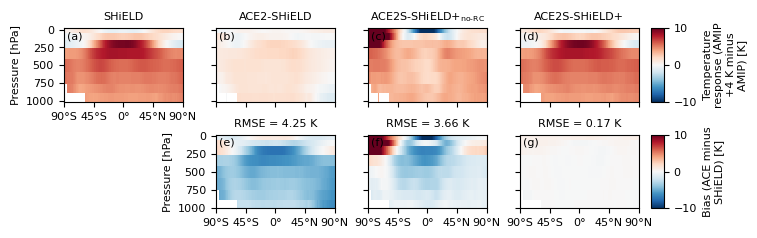

In [16]:
fig, axes, (cax1, cax2) = faceted.faceted(
    2, 
    4, 
    width=6.5, 
    aspect=0.618, 
    cbar_mode="edge", 
    cbar_location="right", 
    cbar_pad=0.125, 
    internal_pad=(0.33, 0.33),
    sharex=False,
    sharey=False,
)

for ax, model in zip(axes, MODELS):
    p1 = pressure_interpolated_response.air_temperature.mean("lon").sel(model=model).plot(ax=ax, vmin=-10, vmax=10, cmap="RdBu_r", x="lat", yincrease=False, add_colorbar=False)
    ax.set_title(LABELS[model])
    ax.set_xlabel("")
    ax.set_ylabel("")
    if model == "SHiELD":
        ax.set_xticks(np.arange(-90, 91, 45))
        ax.set_xticklabels(["90°S", "45°S", "0°", "45°N", "90°N"])
        ax.set_yticks([100000, 75000, 50000, 25000, 0])
        ax.set_yticklabels([1000, 750, 500, 250, 0])
        ax.set_ylabel("Pressure [hPa]")
    else:
        ax.set_xticks(np.arange(-90, 91, 45))
        ax.set_xticklabels(["", "", "", "", ""])
        ax.set_yticks([100000, 75000, 50000, 25000, 0])
        ax.set_yticklabels([])
        ax.set_ylabel("")

for ax, model in zip(axes[5:], MODELS[1:]):
    p2 = pressure_interpolated_response_bias.air_temperature.mean("lon").sel(model=model).plot(ax=ax, vmin=-10, vmax=10, cmap="RdBu_r", x="lat", yincrease=False, add_colorbar=False)
    ax.set_title(f"RMSE = {rmse.air_temperature.sel(model=model).item():0.2f} K")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks(np.arange(-90, 91, 45))
    ax.set_xticklabels(["90°S", "45°S", "0°", "45°N", "90°N"])
    if model == "ACE2-SHiELD":
        ax.set_yticks([100000, 75000, 50000, 25000, 0])
        ax.set_yticklabels([1000, 750, 500, 250, 0])
        ax.set_ylabel("Pressure [hPa]")
    else:
        ax.set_yticks([100000, 75000, 50000, 25000, 0])
        ax.set_yticklabels([])
        ax.set_ylabel("")

axes[4].set_visible(False)

for ax, label in zip(axes[:4] + axes[5:], string.ascii_lowercase):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

fig.colorbar(p1, cax=cax1, label=textwrap.fill("Temperature response (AMIP +4 K minus AMIP) [K]", 15))
fig.colorbar(p2, cax=cax2, label=textwrap.fill("Bias (ACE minus SHiELD) [K]", 15))
fig.patch.set_alpha(0.0)
fig.savefig("figure-S06.png", dpi=300, bbox_inches="tight")
fig.savefig("figure-S06.pdf", bbox_inches="tight")

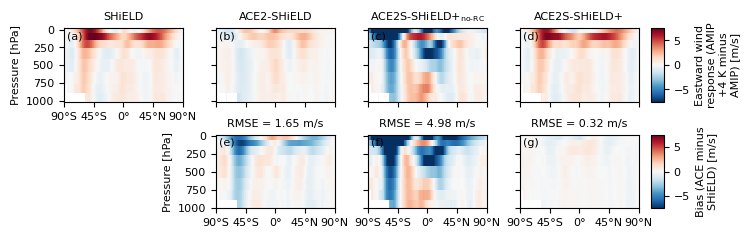

In [17]:
fig, axes, (cax1, cax2) = faceted.faceted(
    2, 
    4, 
    width=6.5, 
    aspect=0.618, 
    cbar_mode="edge", 
    cbar_location="right", 
    cbar_pad=0.125, 
    internal_pad=(0.33, 0.33),
    sharex=False,
    sharey=False,
)

for ax, model in zip(axes, MODELS):
    p1 = pressure_interpolated_response.eastward_wind.mean("lon").sel(model=model).plot(ax=ax, vmin=-7.5, vmax=7.5, cmap="RdBu_r", x="lat", yincrease=False, add_colorbar=False)
    ax.set_title(LABELS[model])
    ax.set_xlabel("")
    ax.set_ylabel("")
    if model == "SHiELD":
        ax.set_xticks(np.arange(-90, 91, 45))
        ax.set_xticklabels(["90°S", "45°S", "0°", "45°N", "90°N"])
        ax.set_yticks([100000, 75000, 50000, 25000, 0])
        ax.set_yticklabels([1000, 750, 500, 250, 0])
        ax.set_ylabel("Pressure [hPa]")
    else:
        ax.set_xticks(np.arange(-90, 91, 45))
        ax.set_xticklabels(["", "", "", "", ""])
        ax.set_yticks([100000, 75000, 50000, 25000, 0])
        ax.set_yticklabels([])
        ax.set_ylabel("")

for ax, model in zip(axes[5:], MODELS[1:]):
    p2 = pressure_interpolated_response_bias.eastward_wind.mean("lon").sel(model=model).plot(ax=ax, vmin=-7.5, vmax=7.5, cmap="RdBu_r", x="lat", yincrease=False, add_colorbar=False)
    ax.set_title(f"RMSE = {rmse.eastward_wind.sel(model=model).item():0.2f} m/s")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks(np.arange(-90, 91, 45))
    ax.set_xticklabels(["90°S", "45°S", "0°", "45°N", "90°N"])
    if model == "ACE2-SHiELD":
        ax.set_yticks([100000, 75000, 50000, 25000, 0])
        ax.set_yticklabels([1000, 750, 500, 250, 0])
        ax.set_ylabel("Pressure [hPa]")
    else:
        ax.set_yticks([100000, 75000, 50000, 25000, 0])
        ax.set_yticklabels([])
        ax.set_ylabel("")

axes[4].set_visible(False)

for ax, label in zip(axes[:4] + axes[5:], string.ascii_lowercase):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

fig.colorbar(p1, cax=cax1, label=textwrap.fill("Eastward wind response (AMIP +4 K minus AMIP) [m/s]", 15))
fig.colorbar(p2, cax=cax2, label=textwrap.fill("Bias (ACE minus SHiELD) [m/s]", 15))
fig.patch.set_alpha(0.0)
fig.savefig("figure-S07.png", dpi=300, bbox_inches="tight")
fig.savefig("figure-S07.pdf", bbox_inches="tight")